# YOLO-World Model

The YOLO-World Model introduces an advanced, real-time UltralyticsYOLOv8-based approach for Open-Vocabulary Detection tasks. This innovation enables the detection of any object within an image based on descriptive texts. By significantly lowering computational demands while preserving competitive performance, YOLO-World emerges as a versatile tool for numerous vision-based applications.

----

Conda env : [cv_playgrounds](../README.md#setup-a-conda-environment)

----

- Ref: 
    - https://docs.ultralytics.com/models/yolo-world/

In [5]:
!nvidia-smi

Fri Nov 21 21:16:44 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.08              Driver Version: 575.57.08      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2080 Ti     On  |   00000000:01:00.0  On |                  N/A |
| 32%   48C    P5             36W /  250W |    8712MiB /  11264MiB |     27%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Download test data

In [4]:
from ultralytics.utils.downloads import safe_download
images = ["bus.jpg", "zidane.jpg"]
for img in images:
  path = safe_download(f"https://ultralytics.com/assets/{img}", dir="temp_assets")

### YOLOWorld

YOLOv8s-worldv2 summary: 148 layers, 12,759,880 parameters, 0 gradients, 51.0 GFLOPs

image 1/1 /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/temp_assets/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 34.8ms
Speed: 1.6ms preprocess, 34.8ms inference, 2.9ms postprocess per image at shape (1, 3, 640, 480)


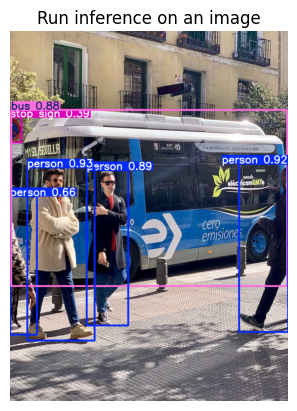

In [1]:
from ultralytics import YOLOWorld
import matplotlib.pyplot as plt
import cv2


# Define an inference source
source = "./temp_assets/bus.jpg"

# Load a pretrained YOLOv8s-worldv2 model
model = YOLOWorld("./temp_model/yolov8s-worldv2.pt")

# Display model information (optional)
model.info()

# Run inference with the RT-DETR-l model on the 'bus.jpg' image
results = model(source)
bgr_image = results[0].plot()
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_image)
plt.axis('off')
plt.title("Run inference on an image")
plt.show()




In [2]:
# Train the model on the COCO8 example dataset for 100 epochs
results = model.train(data="coco8.yaml", epochs=100, imgsz=640)


Ultralytics 8.3.230 🚀 Python-3.10.12 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 10815MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=./temp_model/yolov8s-worldv2.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=


image 1/1 /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/temp_assets/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 9.1ms
Speed: 1.6ms preprocess, 9.1ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 480)


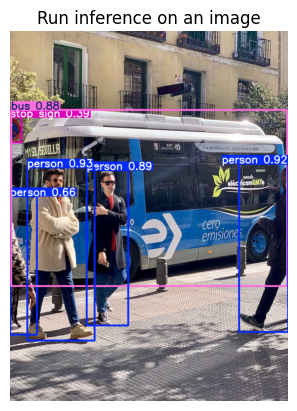

In [3]:
# Run inference with the RT-DETR-l model on the 'bus.jpg' image
results = model("./temp_assets/bus.jpg")
bgr_image = results[0].plot()
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_image)
plt.axis('off')
plt.title("Run inference on an image")
plt.show()


image 1/1 /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/temp_assets/zidane.jpg: 384x640 2 persons, 1 tie, 70.9ms
Speed: 2.0ms preprocess, 70.9ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)


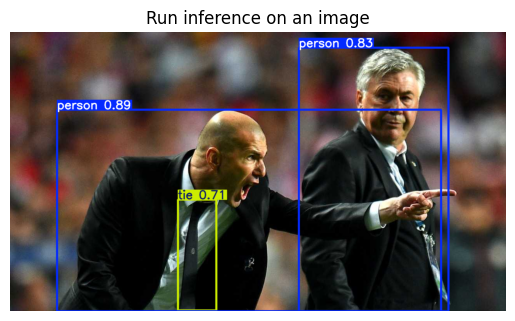

In [4]:
# Run inference with the RT-DETR-l model on the 'bus.jpg' image
results = model("./temp_assets/zidane.jpg")
bgr_image = results[0].plot()
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_image)
plt.axis('off')
plt.title("Run inference on an image")
plt.show()

In [15]:
import gdown
from pathlib import Path

Path("./temp_data").mkdir(exist_ok=True, parents=True)
Path("./temp_output_yoloworld").mkdir(exist_ok=True, parents=True)
id = "1XNs8UoyOJ98iFudll5z-M4nQ3sfeynrW"
test_video_path = "./temp_data/test_nyc.mp4"
gdown.download(id=id, output = test_video_path)

# Track with a YOLO-World model on a video
results = model.track(source=test_video_path, stream=True, save_dir="./temp_output_yoloworld")

Downloading...
From: https://drive.google.com/uc?id=1XNs8UoyOJ98iFudll5z-M4nQ3sfeynrW
To: /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/temp_data/test_nyc.mp4
100%|██████████| 14.4M/14.4M [00:02<00:00, 5.08MB/s]



image 1/1 /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/temp_assets/bus.jpg: 640x480 5 persons, 1 bus, 8.8ms
Speed: 1.9ms preprocess, 8.8ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 480)


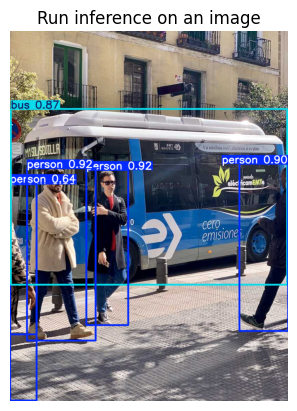

In [17]:
from ultralytics import YOLO

# Initialize a YOLO-World model
model = YOLO("./temp_model/yolov8s-world.pt")  # or choose yolov8m/l-world.pt

# Define custom classes
model.set_classes(["person", "bus"])

# Execute prediction for specified categories on an image
results = model.predict("./temp_assets/bus.jpg")

# # Show results
# results[0].show()
bgr_image = results[0].plot()
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_image)
plt.axis('off')
plt.title("Run inference on an image")
plt.show()


In [19]:
! wget https://github.com/CASIA-LMC-Lab/FastSAM/blob/main/examples/sa_8776.jpg ./temp_data/sa_8776.jpg

--2025-11-22 22:26:16--  https://github.com/CASIA-LMC-Lab/FastSAM/blob/main/examples/sa_8776.jpg
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘sa_8776.jpg’

sa_8776.jpg             [ <=>                ] 177.60K   890KB/s    in 0.2s    

2025-11-22 22:26:16 (890 KB/s) - ‘sa_8776.jpg’ saved [181863]

--2025-11-22 22:26:16--  http://./temp_data/sa_8776.jpg
Resolving . (.)... failed: No address associated with hostname.
wget: unable to resolve host address ‘.’
FINISHED --2025-11-22 22:26:16--
Total wall clock time: 0.7s
Downloaded: 1 files, 178K in 0.2s (890 KB/s)



image 1/1 /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/sa_8776.jpg: 448x640 3 persons, 141.6ms
Speed: 7.8ms preprocess, 141.6ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)


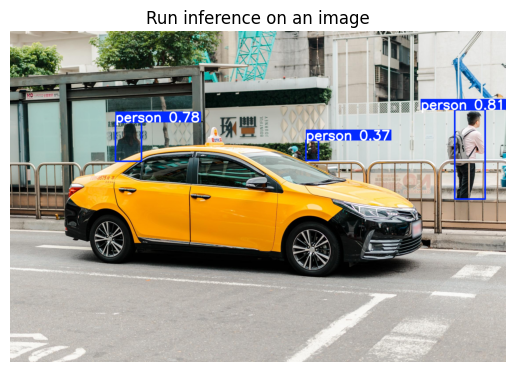

In [21]:
from ultralytics import YOLO

# Initialize a YOLO-World model
model = YOLO("./temp_model/yolov8s-world.pt")  # or choose yolov8m/l-world.pt

# Define custom classes
model.set_classes(["person", "bus"])

# Execute prediction for specified categories on an image
results = model.predict("https://github.com/CASIA-LMC-Lab/FastSAM/blob/main/examples/sa_8776.jpg?raw=true")

# # Show results
# results[0].show()
bgr_image = results[0].plot()
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_image)
plt.axis('off')
plt.title("Run inference on an image")
plt.show()

YOLOv8s-world summary: 161 layers, 13,383,496 parameters, 0 gradients, 71.5 GFLOPs
(161, 13383496, 0, 71.4521088)

Found https://github.com/CASIA-LMC-Lab/FastSAM/blob/main/examples/dogs.jpg locally at dogs.jpg
image 1/1 /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/dogs.jpg: 384x640 3 dogs, 8.5ms
Speed: 1.3ms preprocess, 8.5ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)


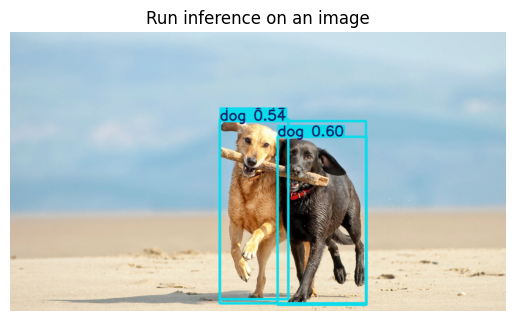

In [25]:
from ultralytics import YOLO

# Initialize a YOLO-World model
model = YOLO("./temp_model/yolov8s-world.pt")  # or choose yolov8m/l-world.pt
print(model.info())

# Define custom classes
model.set_classes(["person", "dog"])

# Execute prediction for specified categories on an image
results = model.predict("https://github.com/CASIA-LMC-Lab/FastSAM/blob/main/examples/dogs.jpg?raw=true")

# # Show results
# results[0].show()
bgr_image = results[0].plot()
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_image)
plt.axis('off')
plt.title("Run inference on an image")
plt.show()